In [1]:
%matplotlib widget
# %matplotlib inline

import numpy as np
import cmath
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

import sys
import os
print(os.getpid())
%cd ../../

module_path = os.path.abspath("./jupyter-notebooks/Xwaves_1D/")
sys.path.append(module_path)

13584
/media/work/docs/codes/QuCF/scripts-py


In [25]:
import xw_1d as xw
import pylib.mix as mix
reload = mix.reload_module

case_to_model = "ref" # "ref", "small" etc, see the function xw.init

In [26]:
# --- perform classical simulations ---
mix.reload_module(xw)

dd_cl = xw.init(case_to_model)
print()
vars_cl = xw.launch(dd_cl)

x_cl = dd_cl["x-plot"]
t_cl = dd_cl["t-norm"]

vx_cl = vars_cl['vx']
vy_cl = vars_cl['vy']
Ex_cl = vars_cl['Ex']
Ey_cl = vars_cl['Ey']
Bz_cl = vars_cl['Bz']
Q_cl = vars_cl['Q']

Wv_cl = vars_cl["Wv"]
We_cl = vars_cl["We"]
Wb_cl = vars_cl["Wb"]
Wq_cl = vars_cl["Wq"]
W_cl = Wv_cl + We_cl + Wb_cl + Wq_cl

Simulation of a --- REF --- case

---------------------------------------------------------------------
--- Classical parameters ---
nqx, nx = 10, 1024
t, nt = 325.000, 1300
norm. time step: 2.504e-01
Courant number is: 7.604e-01

---------------------------------------------------------------------
--- QC parameters ---
QC time step: 2.455
QC normalization of a Hamiltonian matrix: 9.804
QC 1/norm_of_H: 1.020e-01
QC source init. value: 7.071e-01
QC time to simulate: 3186.270
QC number of time steps: 1298

Computation... id-t = 1200
Done
(sumx W[1] - sumx W[-1])/sumx W[1]: -8.681e-04


In [27]:
# -------------------------------------------------------------------
# --- Calculate energy integrated in space ---
# -------------------------------------------------------------------
nt_cl = len(t_cl)
Wt_v_cl = np.array([np.sum(Wv_cl[:,i]) for i in range(nt_cl)])
Wt_e_cl = np.array([np.sum(We_cl[:,i]) for i in range(nt_cl)])
Wt_b_cl = np.array([np.sum(Wb_cl[:,i]) for i in range(nt_cl)])
Wt_q_cl = np.array([np.sum(Wq_cl[:,i]) for i in range(nt_cl)])
Wt_cl = np.array([np.sum(W_cl[:,i]) for i in range(nt_cl)])

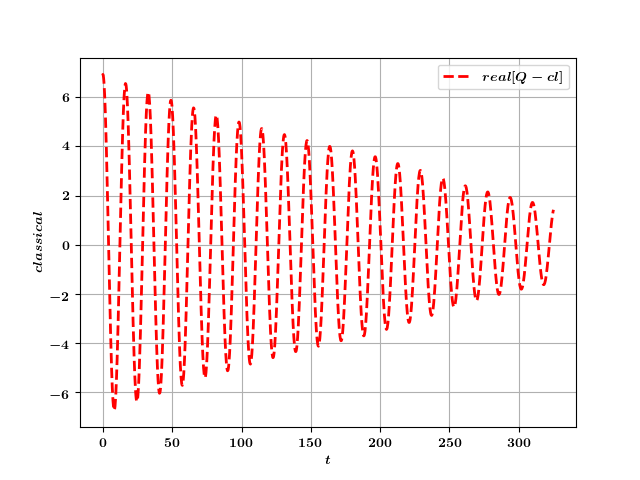

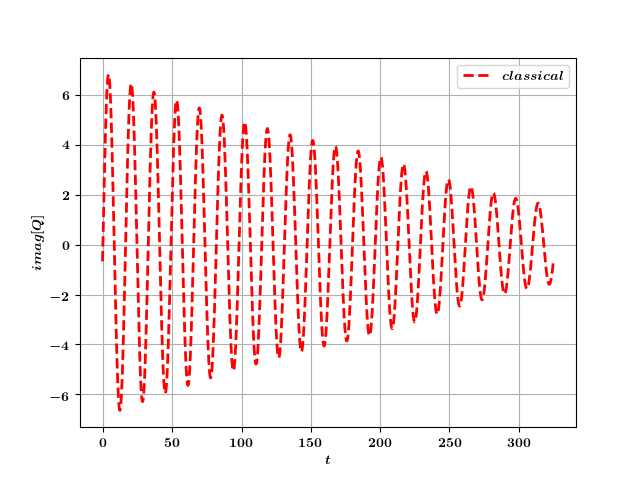

In [29]:
# ----------------------------------------------------------------------------------
# --- Plot signals in time at a particular x-point with classical data ---
# ----------------------------------------------------------------------------------
idx_point = vars_cl['ids-Q'][1] 
# idx_point = 40

y_cl, label_y = vx_cl, "v_x"
# y_cl, label_y = vy_cl, "v_y"
# y_cl, label_y = Ex_cl, "E_x"
# y_cl, label_y = Ey_cl, "E_y"
# y_cl, label_y = Bz_cl, "B_z"
y_cl, label_y = Q_cl, "Q"
# y_cl, label_y = Wv_cl, "Wv"
# y_cl, label_y = We_cl, "We"
# y_cl, label_y = Wb_cl, "Wb"
# y_cl, label_y = Wq_cl, "Wq"
# y_cl, label_y = W_cl, "W"

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(
    t_cl, np.real(y_cl[idx_point,:]), 
    color='r', 
#     marker="s", 
    linewidth = 2, linestyle='--',
    label = "$real[" + label_y + "-cl]$" 
)
plt.xlabel('$t$')
plt.ylabel("$classical$")
ax.legend()
plt.grid(True)
plt.show()


fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(
    t_cl, np.imag(y_cl[idx_point,:]), 
    color='r', 
#     marker="s", 
    linewidth = 2, linestyle='--',
    label = "$classical$" 
)
plt.xlabel('$t$')
plt.ylabel("$imag["+ label_y +"]$")
ax.legend()
plt.grid(True)
plt.show()

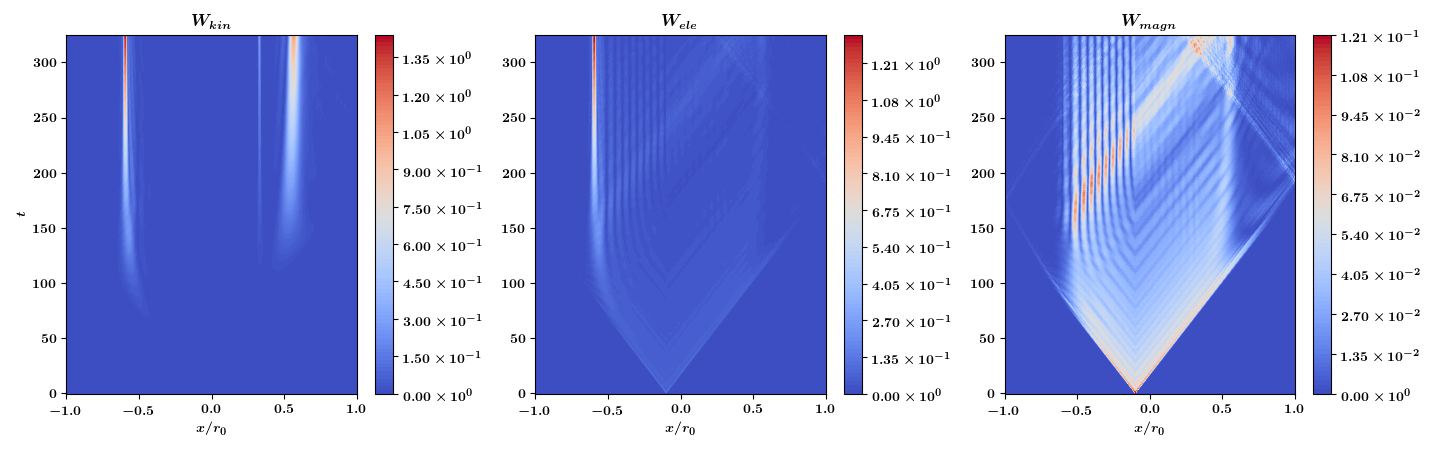

In [35]:
# ----------------------------------------------------------------------------------
# --- Plotting (x,t) distribution ---
# ----------------------------------------------------------------------------------
from matplotlib import ticker

cmap = 'seismic'
cmap = 'bwr'
cmap = 'jet'
cmap = 'coolwarm'

def fmt(x, pos):
    a, b = '{:.2e}'.format(x).split('e')
    b = int(b)
    return r'${} \times 10^{{{}}}$'.format(a, b)

def plot_xy(fig, axs, ax, f_plot, title, flag_label_x, flag_label_y):
    cs = ax.contourf(XX, YY, np.real(f_plot.T), levels=100, cmap=cmap)
    if flag_label_x: ax.set_xlabel('$x/r_0$')
    if flag_label_y: ax.set_ylabel('$t$')
    ax.set_title('$' + title + '$')
    fig.colorbar(cs, ax = ax, format=ticker.FuncFormatter(fmt))
    return cs


XX, YY = np.meshgrid(x_cl, t_cl)
fig, axs = plt.subplots(1, 3, figsize=(9.6 + 4.8,4.5))

cs1 = plot_xy(fig, axs, axs[0], Wv_cl, 'W_{kin}', True, True)
cs2 = plot_xy(fig, axs, axs[1], We_cl, 'W_{ele}', True, False)
cs3 = plot_xy(fig, axs, axs[2], Wb_cl, 'W_{magn}', True, False)

# fig.colorbar(cs2, ax = axs, format=ticker.FuncFormatter(fmt), shrink=0.5)

plt.tight_layout()
plt.show()

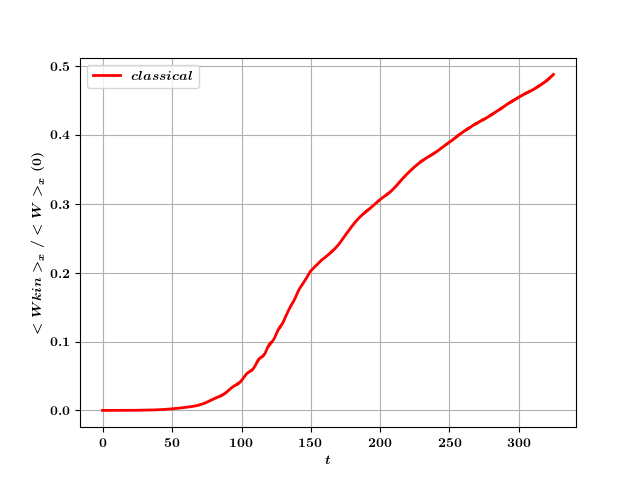

In [30]:
# ----------------------------------------------------------------------------------
# --- Plotting energy integrated in time ---
# ----------------------------------------------------------------------------------
y_cl, label_y = Wt_v_cl, "<Wkin>_x"
# y_cl, label_y = Wt_e_cl, "<We>_x"
# y_cl, label_y = Wt_b_cl, "<Wb>_x"
# y_cl, label_y = Wt_q_cl, "<Wq>_x"
# y_cl, label_y = Wt_cl,   "<W>_x"

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(
    t_cl, y_cl[:]/Wt_cl[1],  
    color='r', 
    linewidth = 2, linestyle='-',
    label = "$classical$" 
)
plt.xlabel('$t$')
plt.ylabel("$"+ label_y +"/<W>_x(0)$")
ax.legend()
plt.grid(True)
plt.show()

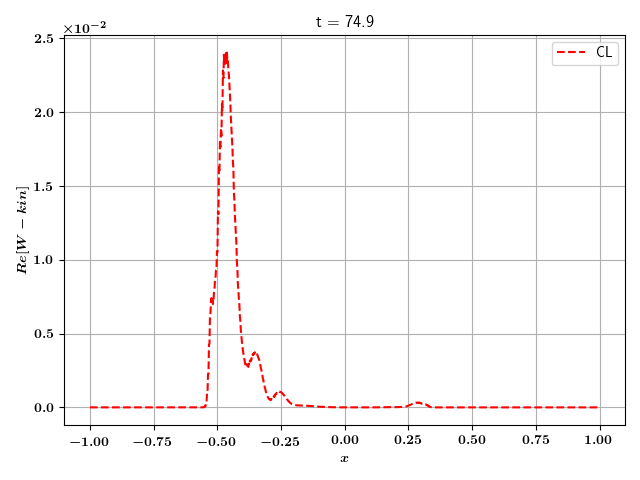

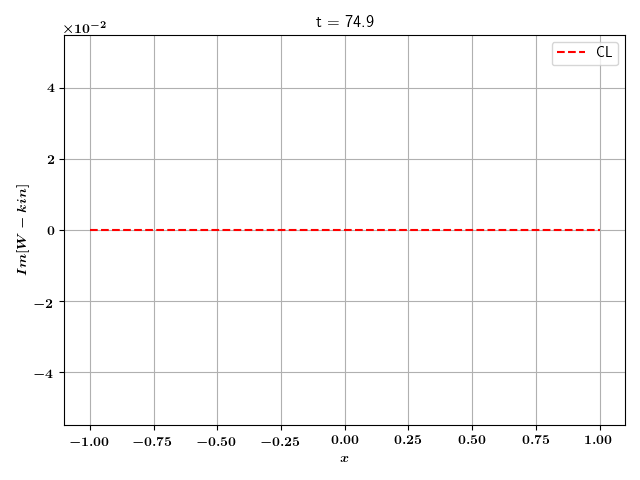

In [32]:
# ----------------------------------------------------------------------------------
# --- Plotting spatial distribution at a chosen time instant ---
# ----------------------------------------------------------------------------------
reload(xw)
    
# y_cl, label_y = vx_cl, "\\xi_x"
# y_cl, label_y = vy_cl, "\\xi_y"
# y_cl, label_y = Ex_cl, "E_x"
# y_cl, label_y = Ey_cl, "E_y"
# y_cl, label_y = Bz_cl, "B_z"
y_cl, label_y = Wv_cl, "W-kin"

# id_t_point = len(t)-1
id_t_point = 300

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_cl, np.real(y_cl[:,id_t_point]), "r--", label = "CL")
plt.xlabel('$x$')
plt.ylabel('$Re[' + label_y + ']$')
ax.ticklabel_format(axis='y', style='sci', scilimits=[0,0])
plt.title("t = {:0.1f}".format(t_cl[id_t_point]))
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_cl, np.imag(y_cl[:,id_t_point]), "r--", label = "CL")
plt.xlabel('$x$')
plt.ylabel('$Im[' + label_y + ']$')
ax.ticklabel_format(axis='y', style='sci', scilimits=[0,0])
plt.title("t = {:0.1f}".format(t_cl[id_t_point]))
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()